In [30]:
#IMPORT LIBRARIES
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, zscore

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [31]:
# LOAD DATASET
# Upload the csv to your notebook and give its path here
df = pd.read_csv("cancer patient data sets.csv")
df

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,2,7,8,2,4,5,3,High
996,996,P996,37,2,6,8,7,7,7,6,...,9,6,5,7,2,4,3,1,4,High
997,997,P997,25,2,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
998,998,P998,18,2,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [32]:
print(df.head())

   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1              2            4             5   
1      1        P10   17       1              3            1             5   
2      2       P100   35       1              4            5             6   
3      3      P1000   37       1              7            7             7   
4      4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  ...  Fatigue  \
0                     4             3                     2  ...        3   
1                     3             4                     2  ...        1   
2                     5             5                     4  ...        8   
3                     7             6                     7  ...        4   
4                     7             7                     6  ...        3   

   Weight Loss  Shortness of Breath  Wheezing  Swallowing Difficulty

In [33]:
print(df.shape)

(1000, 26)


In [34]:
#BASIC INFORMATION
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [35]:
print(df.describe())

             index          Age       Gender  Air Pollution  Alcohol use  \
count  1000.000000  1000.000000  1000.000000      1000.0000  1000.000000   
mean    499.500000    37.174000     1.402000         3.8400     4.563000   
std     288.819436    12.005493     0.490547         2.0304     2.620477   
min       0.000000    14.000000     1.000000         1.0000     1.000000   
25%     249.750000    27.750000     1.000000         2.0000     2.000000   
50%     499.500000    36.000000     1.000000         3.0000     5.000000   
75%     749.250000    45.000000     2.000000         6.0000     7.000000   
max     999.000000    73.000000     2.000000         8.0000     8.000000   

       Dust Allergy  OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
count   1000.000000           1000.000000   1000.000000           1000.000000   
mean       5.165000              4.840000      4.580000              4.380000   
std        1.980833              2.107805      2.126999              1.8

In [36]:
#CHECK MISSING VALUES
print(df.isnull().sum())

index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64


In [37]:
#DROP UNNECESSARY COLUMNS (if any)
#Commonly the dataset has a "Patient Id" column
#Remove it if present
if "Patient Id" in df.columns:
    df = df.drop(columns=["Patient Id"])

In [38]:
#TARGET VARIABLE
#In this dataset, the target column is normally:
#"Level"  (Low / Medium / High)
#We convert it to a binary lung cancer risk label
print(df["Level"].value_counts())

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64


In [39]:
#Convert to binary
#Low -> 0 , Medium & High -> 1
df["LungCancer"] = df["Level"].map({"Low":0, "Medium":1, "High":1})
df = df.drop(columns=["Level"])
print(df["LungCancer"].value_counts())

LungCancer
1    697
0    303
Name: count, dtype: int64


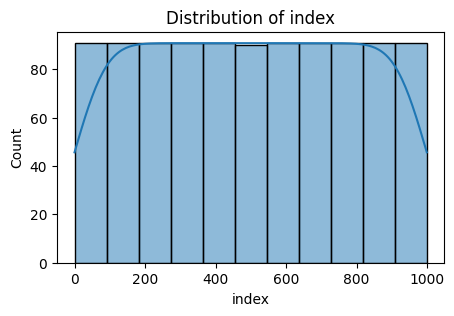

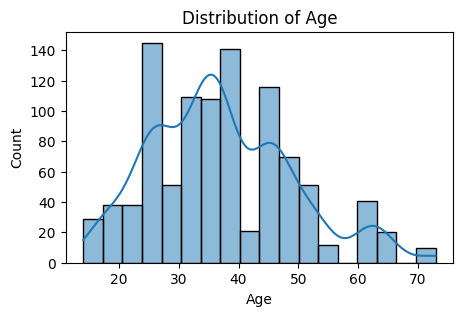

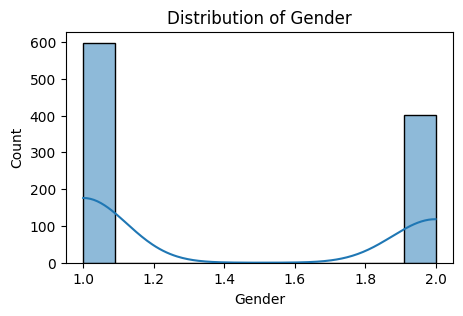

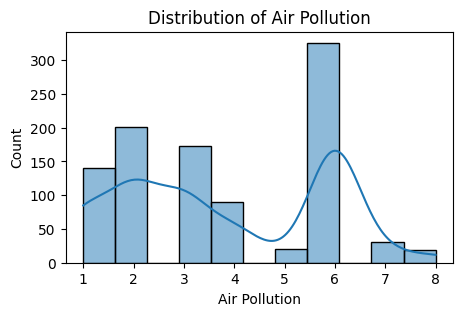

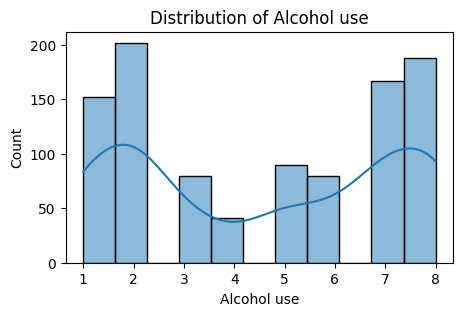

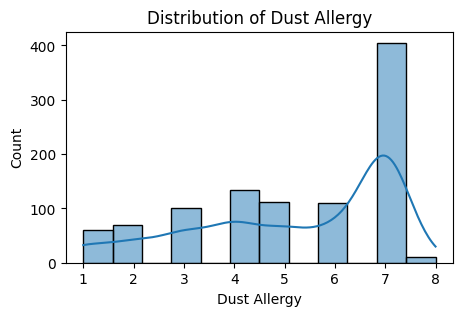

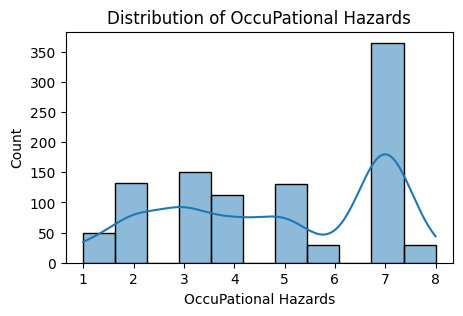

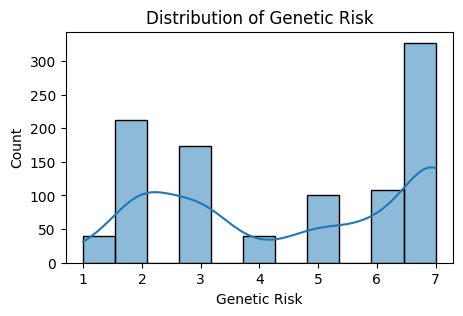

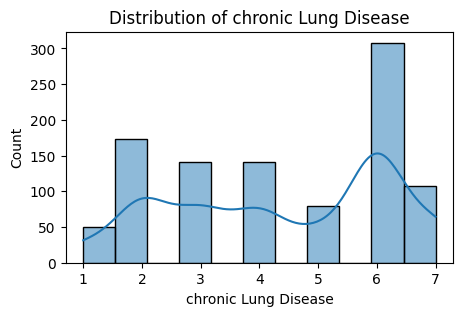

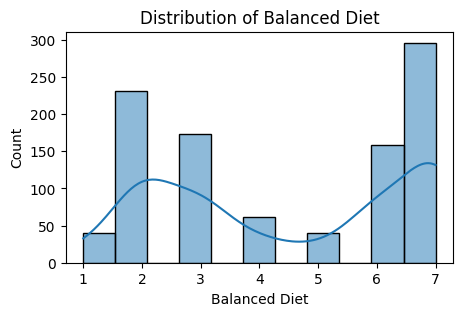

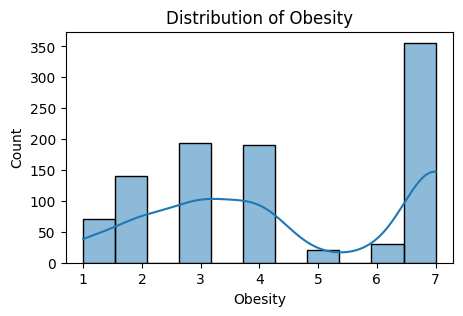

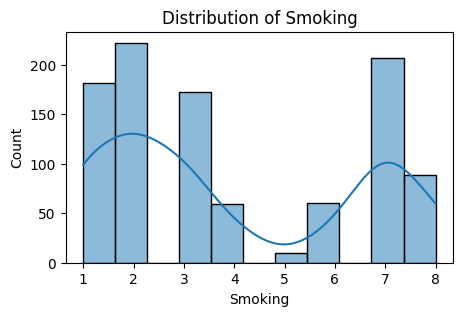

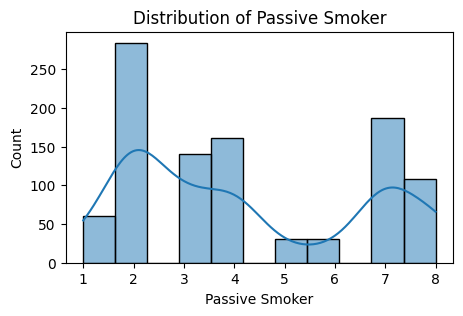

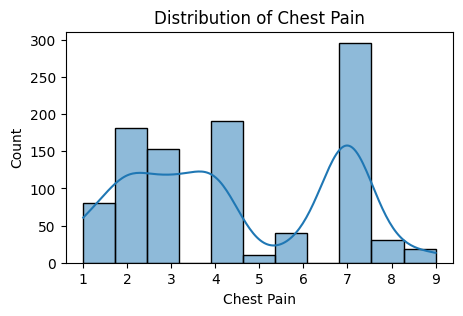

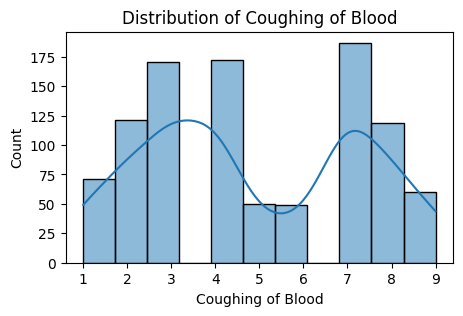

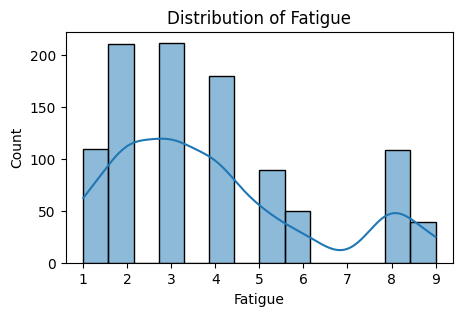

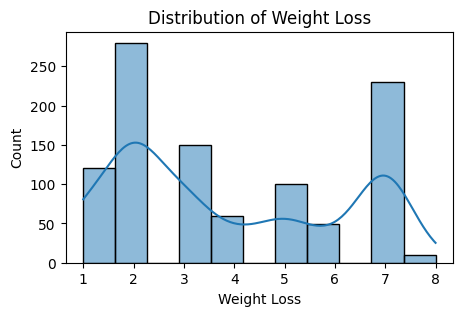

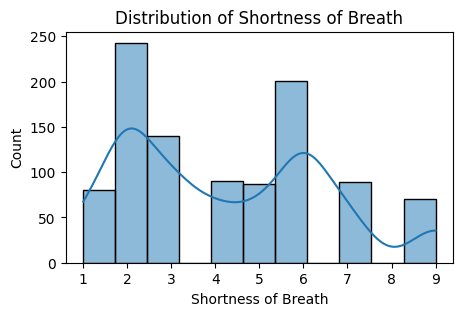

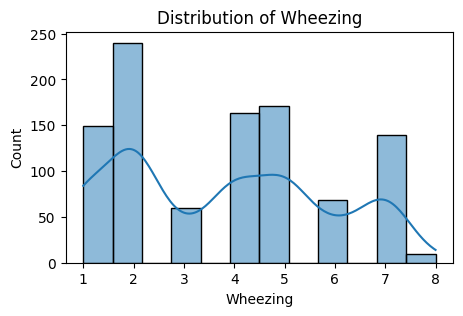

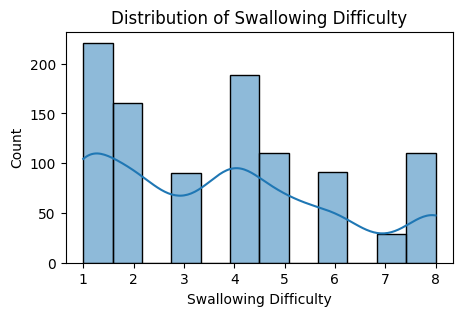

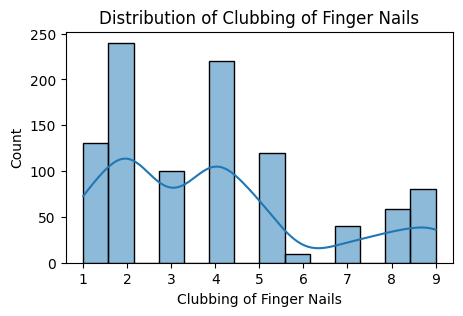

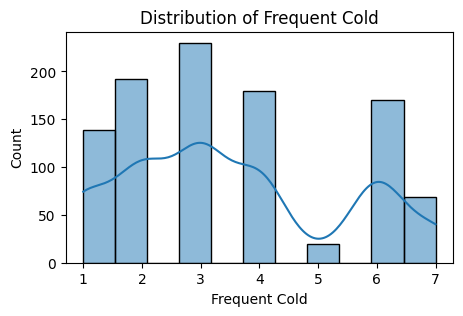

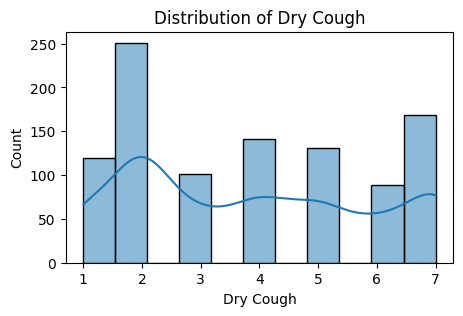

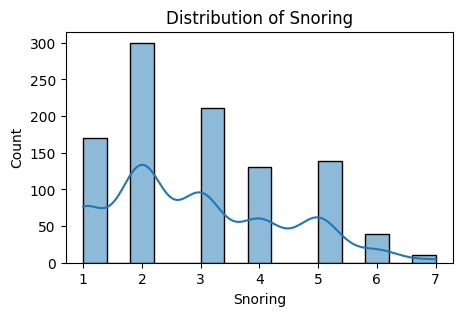

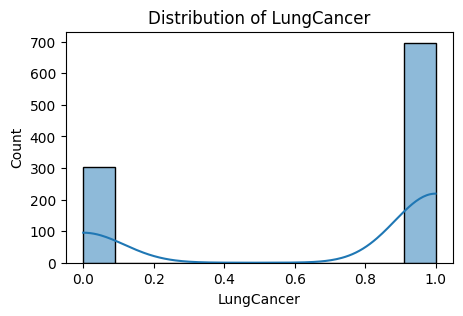

In [40]:
#UNIVARIATE ANALYSIS
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [41]:
#OUTLIER DETECTION (Z-SCORE)
z_scores = np.abs(zscore(df[numeric_cols]))
outliers = (z_scores > 3).any(axis=1)
print("Total outliers:", outliers.sum())

Total outliers: 0


In [42]:
#SEPARATE FEATURES AND TARGET
X = df.drop("LungCancer", axis=1)
y = df["LungCancer"]

In [43]:
#IDENTIFY CATEGORICAL & NUMERICAL
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: []
Numerical: ['index', 'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']


In [44]:
#CHI-SQUARE TEST (CATEGORICAL)
print("\nChi-square test results\n")
for col in categorical_features:
    contingency = pd.crosstab(X[col], y)
    chi2, p, dof, exp = chi2_contingency(contingency)
    print(f"{col} -> p-value = {p}")


Chi-square test results



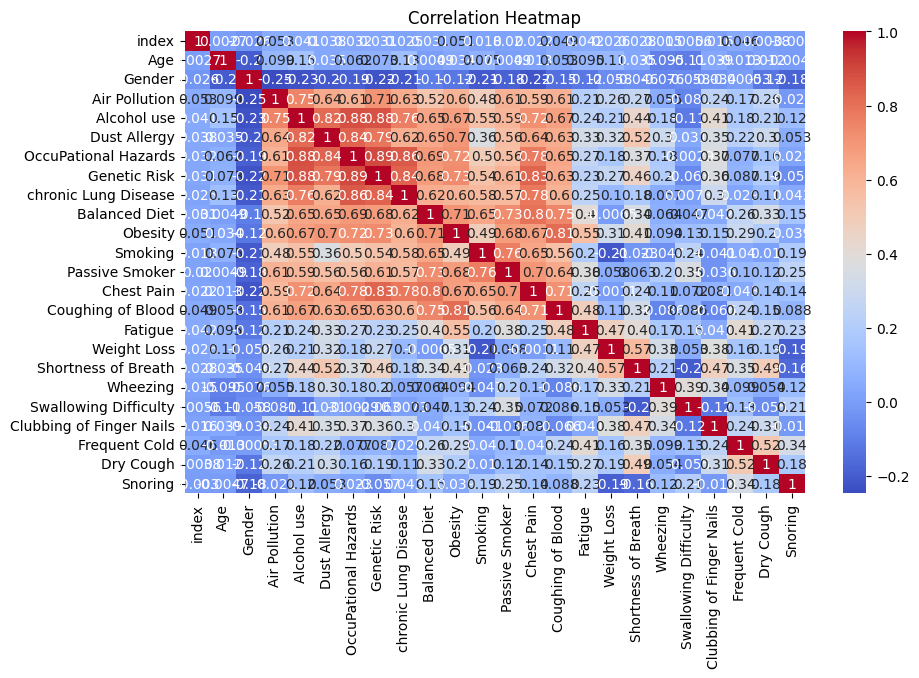

In [45]:
#CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [46]:
#PREPROCESSING PIPELINE
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [47]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [48]:
#MODELS
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

In [49]:
#MODEL TRAINING AND EVALUATION
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model.named_steps["classifier"], "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = np.nan
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = [acc, prec, rec, f1, roc]
    print("\n",name)
    print(classification_report(y_test, y_pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       209

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


 Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       209

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       209

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1

In [50]:
#RESULTS TABLE
results_df = pd.DataFrame(results,
                           index=["Accuracy","Precision","Recall","F1","ROC-AUC"]).T
print(results_df)
# Save for thesis table
results_df.to_csv("model_results.csv")

                     Accuracy  Precision  Recall   F1  ROC-AUC
Logistic Regression       1.0        1.0     1.0  1.0      1.0
Decision Tree             1.0        1.0     1.0  1.0      1.0
Random Forest             1.0        1.0     1.0  1.0      1.0


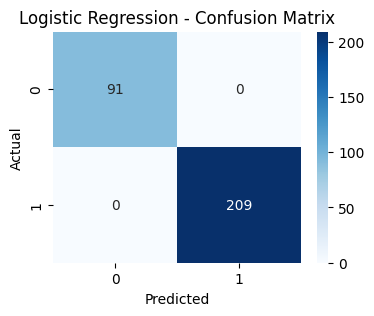

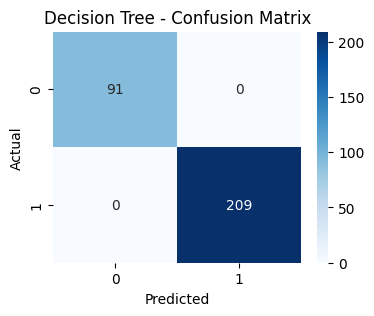

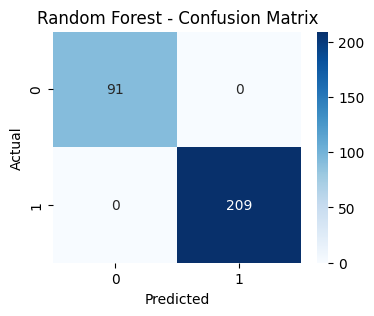

In [51]:
#CONFUSION MATRICES
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

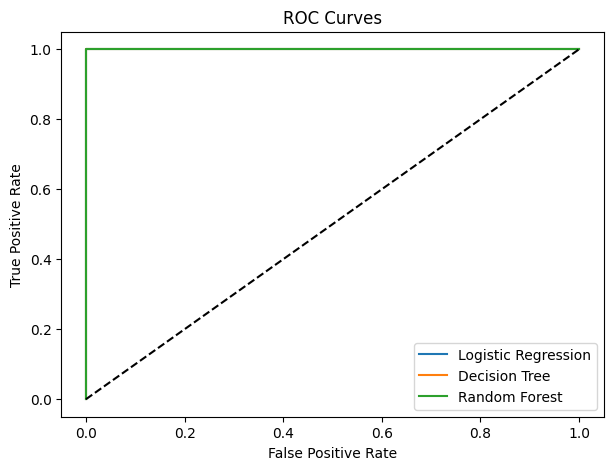

In [52]:
#ROC CURVES
plt.figure(figsize=(7,5))
for name, model in models.items():
    if hasattr(model.named_steps["classifier"], "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [53]:
#CROSS VALIDATION
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name} CV ROC-AUC Mean: {scores.mean():.4f}")

Logistic Regression CV ROC-AUC Mean: 1.0000
Decision Tree CV ROC-AUC Mean: 1.0000
Random Forest CV ROC-AUC Mean: 1.0000


                     Feature  Importance
18                  Wheezing    0.112399
4                Alcohol use    0.110232
5               Dust Allergy    0.103008
10                   Obesity    0.093397
15                   Fatigue    0.086190
7               Genetic Risk    0.071470
6       OccuPational Hazards    0.065145
19     Swallowing Difficulty    0.040979
20  Clubbing of Finger Nails    0.040391
23                   Snoring    0.038521
16               Weight Loss    0.032099
21             Frequent Cold    0.032010
17       Shortness of Breath    0.031669
9              Balanced Diet    0.030057
14         Coughing of Blood    0.026261


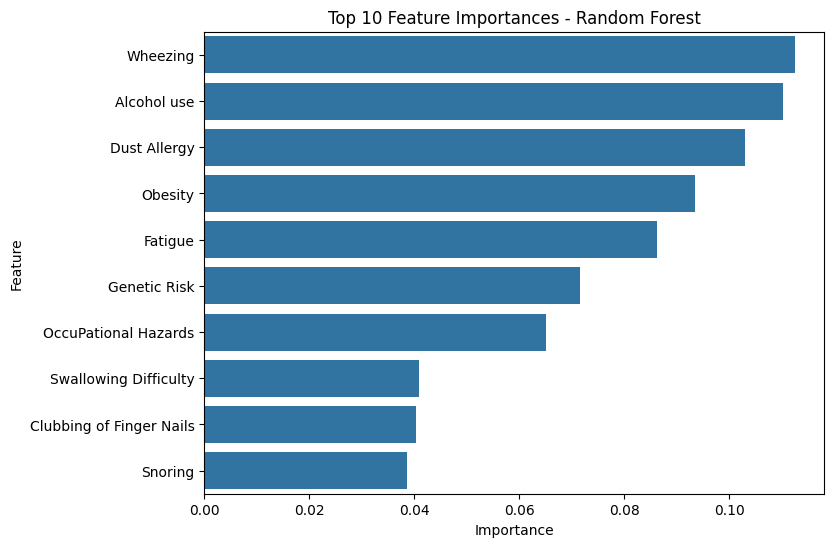

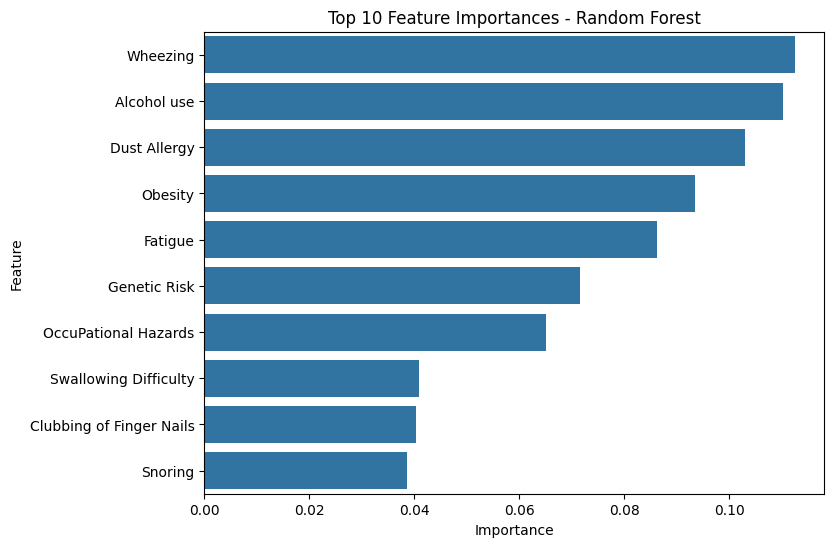

In [54]:
#FEATURE IMPORTANCE (RANDOM FOREST)
rf_model.fit(X_train, y_train)

# Since this dataset has no categorical features,
# we only use numerical feature names

feature_names = numerical_features

importances = rf_model.named_steps["classifier"].feature_importances_

fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(fi.head(15))

plt.figure(figsize=(8,6))
sns.barplot(data=fi.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

fi.to_csv("feature_importance.csv", index=False)

plt.figure(figsize=(8,6))
sns.barplot(data=fi.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

fi.to_csv("feature_importance.csv", index=False)

In [55]:
#LOGISTIC REGRESSION COEFFICIENTS
log_reg.fit(X_train, y_train)

coefs = log_reg.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(15))
coef_df.to_csv("logistic_coefficients.csv", index=False)

                     Feature  Coefficient
18                  Wheezing     2.060879
10                   Obesity     2.044877
20  Clubbing of Finger Nails     1.714383
12            Passive Smoker     1.530293
23                   Snoring     1.403044
14         Coughing of Blood     1.370197
19     Swallowing Difficulty     1.324170
15                   Fatigue     1.053184
22                 Dry Cough     1.019717
21             Frequent Cold     1.013214
5               Dust Allergy     0.810677
7               Genetic Risk     0.806578
1                        Age     0.756571
4                Alcohol use     0.462688
17       Shortness of Breath     0.252030


In [56]:
#SAVE TEST PREDICTIONS
test_predictions = X_test.copy()
test_predictions["Actual"] = y_test.values
test_predictions["Predicted_RF"] = rf_model.predict(X_test)

test_predictions.to_csv("test_predictions.csv", index=False)

print("Pipeline completed successfully.")

Pipeline completed successfully.
